In [23]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from collections import Counter
import re

In [24]:
conn = sqlite3.connect("news.db")


In [25]:
# compare average length of fake and real news articles
length_df = pd.read_sql_query("""
    SELECT l.label, AVG(LENGTH(a.text)) AS avg_length, MIN(LENGTH(a.text)) AS min_length, MAX(LENGTH(a.text)) AS max_length
    FROM Articles a
    JOIN Labels l ON a.article_id = l.article_id
    GROUP BY l.label
""", conn)

length_df
# min length of 1 indicates possibly bad rows that need to be taken care of during cleaning/preprocessing
# fake news articles tend to be longer than real news articles, possibly in order to boost credibility by using more words?

,label,avg_length,min_length,max_length
0,fake,2547.396235,1,51794
1,real,2383.278517,1,29781


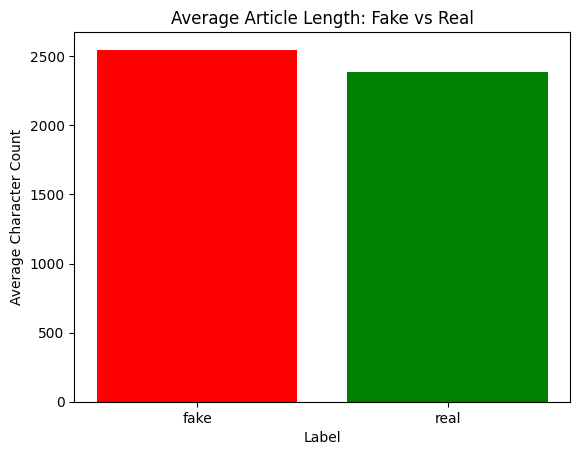

In [26]:
plt.bar(length_df["label"], length_df["avg_length"], color=["red", "green"])
plt.title("Average Article Length: Fake vs Real")
plt.xlabel("Label")
plt.ylabel("Average Character Count")
plt.show()

In [27]:
# check out subject distribution for fake and real news
subject_df = pd.read_sql_query("""
    SELECT a.subject, l.label, COUNT(*) AS article_count
    FROM Articles a
    JOIN Labels l ON a.article_id = l.article_id
    GROUP BY a.subject, l.label
    ORDER BY article_count DESC
""", conn)

subject_df
# results are a little strange as subject names are not shared between real and fake news records
# subject might have been a feature added by the person who made the dataset rather than the article itself, so I'm a little 
# suspicious of relying on subject as a parameter for the model (might classify based on that alone rather than the actual
# content of the article and can overfit the model)

,subject,label,article_count
0,politicsNews,real,11272
1,worldnews,real,10145
2,News,fake,9050
3,politics,fake,6841
4,left-news,fake,4459
5,Government News,fake,1570
6,US_News,fake,783
7,Middle-east,fake,778


In [ ]:
# maybe there are clusters around certain dates?
date_df = pd.read_sql_query("""
    SELECT a.date, l.label, COUNT(*) AS article_count
    FROM Articles a
    JOIN Labels l ON a.article_id = l.article_id
    GROUP BY a.date, l.label
    ORDER BY a.date
""", conn)
date_df["date"] = pd.to_datetime(date_df["date"], errors="coerce")
print(date_df.head(10))
print(date_df.tail(10))
# datasets run from arund 2015-2018
# some NaT rows at bottom (maybe other places as well) which might need to be dropped after closer inspection
date_df = date_df.dropna(subset=["date"])
fake_dates = date_df[date_df["label"] == "fake"]
real_dates = date_df[date_df["label"] == "real"]

plt.figure(figsize=(12, 5))
plt.plot(fake_dates["date"], fake_dates["article_count"], color="red", label="Fake", alpha=0.7)
plt.plot(real_dates["date"], real_dates["article_count"], color="green", label="Real", alpha=0.7)
plt.title("Article Distribution Over Time")
plt.xlabel("Date")
plt.ylabel("Article Count")
plt.legend()
plt.tight_layout()
plt.show()
# terrible graph, too many points make it incomprehensible -- going to have to aggregate the data, probably by month

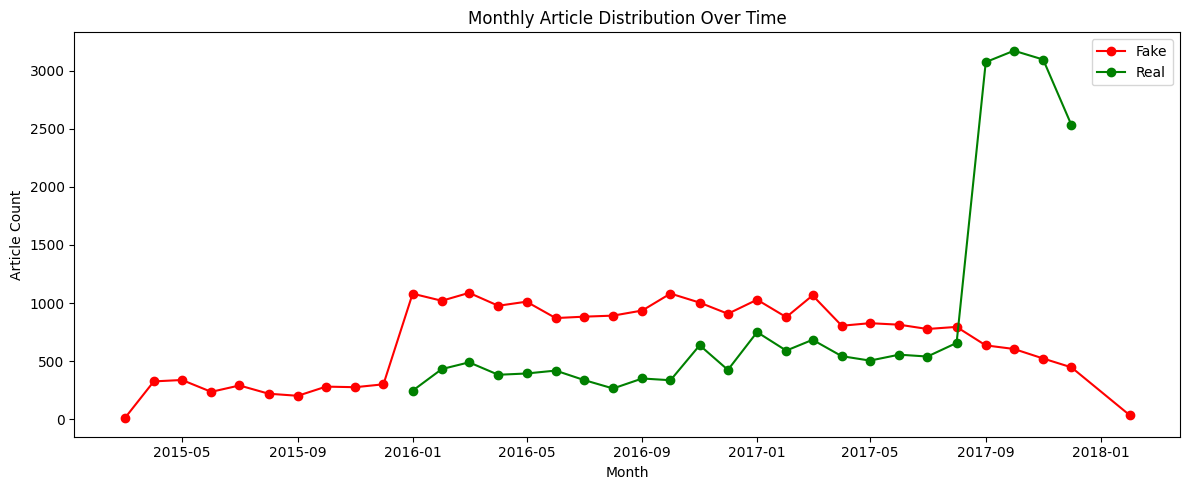

In [29]:
date_df["month"] = date_df["date"].dt.to_period("M")

monthly = date_df.groupby(["month", "label"])["article_count"].sum().reset_index()
monthly["month"] = monthly["month"].dt.to_timestamp()

fake_monthly = monthly[monthly["label"] == "fake"]
real_monthly = monthly[monthly["label"] == "real"]

plt.figure(figsize=(12, 5))
plt.plot(fake_monthly["month"], fake_monthly["article_count"], color="red", label="Fake", marker="o")
plt.plot(real_monthly["month"], real_monthly["article_count"], color="green", label="Real", marker="o")
plt.title("Monthly Article Distribution Over Time")
plt.xlabel("Month")
plt.ylabel("Article Count")
plt.legend()
plt.tight_layout()
plt.show()
# fake news has much bigger spread of dates (2015-2018) compared to real news (only 2016-2018)
# real news has a spike in articles in Sep 2017 - Jan 2018
# dates aren't consistent between fake and real news observations, making me question if its a reliable parameter
# I'm starting to think the brunt of training will be on the article content itself rather than metadata

In [31]:
# analyzing word frequencies
# nltk.download("stopwords")
# filtering out common words like "the", "a", etc. whose frequencies have no significant meaning
stop_words = set(stopwords.words("english"))
def get_top_words(text_string, n=20):
    all_text = " ".join(text_string).lower()
    words = re.findall(r'\b[a-z]+\b', all_text) # removes punctuation and numbers
    filtered = [w for w in words if w not in stop_words and len(w) > 2] # filters out short words and stopwords
    return Counter(filtered).most_common(n)
raw_text = pd.read_sql_query("""
    SELECT a.title, a.text, l.label
    FROM Articles a
    JOIN Labels l ON a.article_id = l.article_id
""", conn)

fake_words = get_top_words(raw_text[raw_text["label"] == "fake"]["text"])
real_words = get_top_words(raw_text[raw_text["label"] == "real"]["text"])

print("Top 20 words in FAKE articles:")
print(fake_words)
print("\nTop 20 words in REAL articles:")
print(real_words)
# from this alone, I can see that the fake news articles tend to focus on specific political figures, stating their name a lot
# this can indicate how fake news articles tend to serve as political propaganda (presence of twitter AKA social media probably
# being used as a source for these fake news articles)

# Reuters is frequent in real news articles, and it is the name of a very reliable news & media organization that is widely 
# used as a primary source in other news outlets (indicating credibility through citing of trusted sources)

# real news also tends to use less personal diction like "president" rather than name dropping "trump" or "obama"

# diction and vocabulary just seems more formal in the real news articles than fake

Top 20 words in FAKE articles:
[('trump', 79300), ('said', 33763), ('president', 27715), ('people', 26570), ('one', 24531), ('would', 23562), ('clinton', 19173), ('obama', 18797), ('like', 18097), ('donald', 17671), ('also', 15403), ('news', 14620), ('new', 14394), ('hillary', 14122), ('even', 14011), ('time', 13844), ('state', 13463), ('white', 13189), ('via', 12776), ('twitter', 11721)]

Top 20 words in REAL articles:
[('said', 99062), ('trump', 54700), ('would', 31605), ('reuters', 28976), ('president', 28177), ('state', 21025), ('government', 18846), ('new', 16917), ('states', 16652), ('house', 16640), ('republican', 16243), ('also', 15954), ('united', 15590), ('people', 15287), ('year', 14777), ('told', 14245), ('could', 13711), ('one', 13396), ('washington', 12988), ('party', 12759)]


In [33]:
fake_title_words = get_top_words(raw_text[raw_text["label"] == "fake"]["title"])
real_title_words = get_top_words(raw_text[raw_text["label"] == "real"]["title"])

print("Top 20 words in FAKE titles:")
print(fake_title_words)
print("\nTop 20 words in REAL titles:")
print(real_title_words)
# "anti" - negative sentiment? propaganda?
# "video", "watch", "breaking" - clickbaitey titles

Top 20 words in FAKE titles:
[('trump', 9338), ('video', 8477), ('obama', 2582), ('hillary', 2319), ('watch', 1937), ('president', 1146), ('clinton', 1138), ('new', 905), ('black', 896), ('breaking', 896), ('news', 883), ('white', 875), ('donald', 848), ('gop', 807), ('america', 703), ('media', 702), ('muslim', 675), ('one', 633), ('anti', 609), ('tweets', 602)]

Top 20 words in REAL titles:
[('trump', 5561), ('says', 2981), ('house', 1449), ('russia', 977), ('north', 926), ('korea', 898), ('new', 875), ('white', 818), ('china', 782), ('senate', 759), ('court', 725), ('bill', 686), ('state', 666), ('obama', 665), ('clinton', 656), ('republican', 636), ('tax', 621), ('election', 582), ('may', 559), ('deal', 553)]


In [34]:
conn.close()